In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('expense.csv')


In [5]:
df

,Date,Category,Description,Amount
0,08-07-2026,Transportation,Lyft,24.78
1,08-15-2026,Food,Ubereats,25.41
2,08-03-2026,Entertainment,Cineplex,16.00
3,08-04-2026,Entertainment,Netflix subscription,24.54
4,08-10-2026,Shopping,Personal care,55.00
5,08-15-2026,Transportation,Uber,16.00
6,08-20-2026,Food,Grocery,70.00
7,08-02-2026,Shopping,Clothes,100.21
8,08-17-2026,School,School supplies,50.00
9,08-17-2026,Transportation,Bus pass,50.45


In [6]:
df.head()


,Date,Category,Description,Amount
0,08-07-2026,Transportation,Lyft,24.78
1,08-15-2026,Food,Ubereats,25.41
2,08-03-2026,Entertainment,Cineplex,16.00
3,08-04-2026,Entertainment,Netflix subscription,24.54
4,08-10-2026,Shopping,Personal care,55.00


In [7]:
df.tail()

,Date,Category,Description,Amount
22,11-01-2026,Rent,Apartment,600.00
23,11-25-2026,Transportation,Uber,20.83
24,10-04-2026,Transportation,Lyft,10.49
25,09-06-2026,School,Text book,90.00
26,10-25-2026,School,Printing,5.59


In [8]:
df.columns

Index(['Date', 'Category', 'Description', 'Amount'], dtype='str')

In [9]:
df['Amount']

0     24.0
1     25.0
2     16.0
3     24.0
4     55.0
5     16.0
6     70.0
7    100.0
8     50.0
9     50.0
Name: Amount, dtype: float64

In [11]:
df['Amount'].sum()

np.float64(430.0)

In [12]:
df['Amount'].mean()

np.float64(43.0)

In [13]:
df['Amount'].min()

np.float64(16.0)

In [14]:
df['Amount'].max()

np.float64(100.0)

In [18]:
category_totals = df.groupby('Category')['Amount'].sum()

In [19]:
category_totals

Category
Entertainment      40.0
Food               95.0
School             50.0
Shopping          155.0
Transportation     90.0
Name: Amount, dtype: float64

In [17]:
df.groupby('Category').size()

Category
Entertainment     2
Food              2
School            1
Shopping          2
Transportation    3
dtype: int64

In [16]:
import matplotlib.pyplot as plt

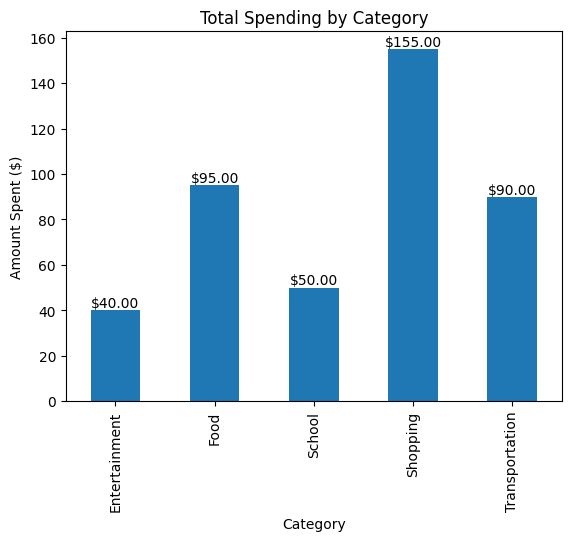

In [28]:
ax = category_totals.plot(kind='bar')

plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Amount Spent ($)')

for i, value in enumerate(category_totals):
    ax.text(i, value, f'${value:.2f}', ha='center', va='bottom')

plt.show()

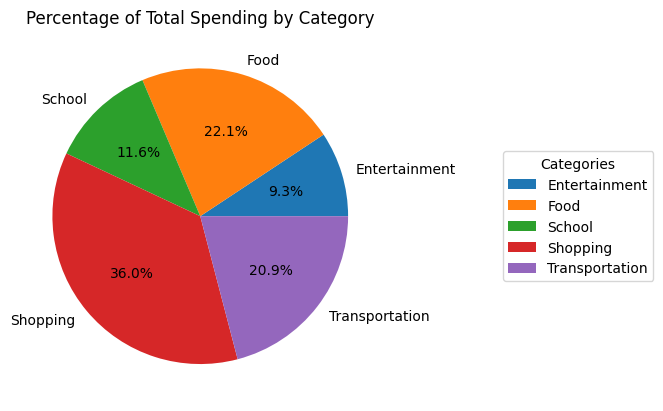

In [31]:
category_totals.plot(kind='pie', autopct='%1.1f%%')

plt.title('Percentage of Total Spending by Category')
plt.ylabel('')

plt.legend(
           title='Categories',
           bbox_to_anchor=(1.3,0.5),
           loc='center left')

plt.show()

In [33]:
df['Date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df['Date'].dtype

dtype('<M8[us]')

In [40]:
daily_spending = df.groupby('Date')['Amount'].sum()

In [41]:
daily_spending

Date
2026-08-02    100.0
2026-08-03     16.0
2026-08-04     24.0
2026-08-07     24.0
2026-08-10     55.0
2026-08-15     41.0
2026-08-17    100.0
2026-08-20     70.0
Name: Amount, dtype: float64

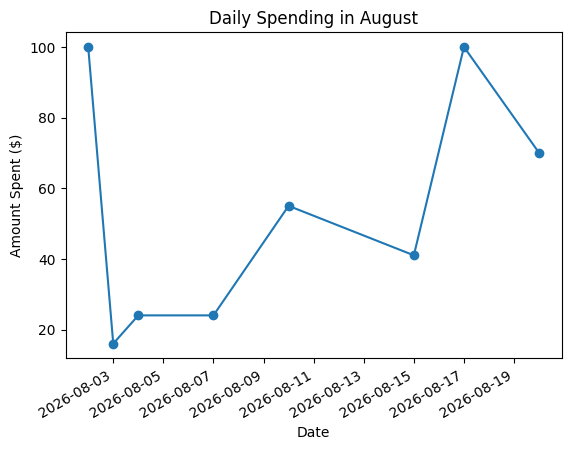

In [42]:
daily_spending.plot(kind='line', marker='o')

plt.title('Daily Spending in August')
plt.xlabel('Date')
plt.ylabel('Amount Spent ($)' )

plt.show()

In [43]:
daily_spending.max()

np.float64(100.0)

In [46]:
daily_spending.loc[daily_spending.idxmax()]

np.float64(100.0)

In [10]:
df['Month'] = df['Date'].dt.month

In [11]:
df.head()

,Date,Category,Description,Amount,Month
0,2026-08-07,Transportation,Lyft,24.78,8
1,2026-08-15,Food,Ubereats,25.41,8
2,2026-08-03,Entertainment,Cineplex,16.00,8
3,2026-08-04,Entertainment,Netflix subscription,24.54,8
4,2026-08-10,Shopping,Personal care,55.00,8


In [13]:
monthly_totals = df.groupby('Month')['Amount'].sum()

In [14]:
monthly_totals

Month
8     432.39
9     891.27
10    779.87
11    825.83
Name: Amount, dtype: float64

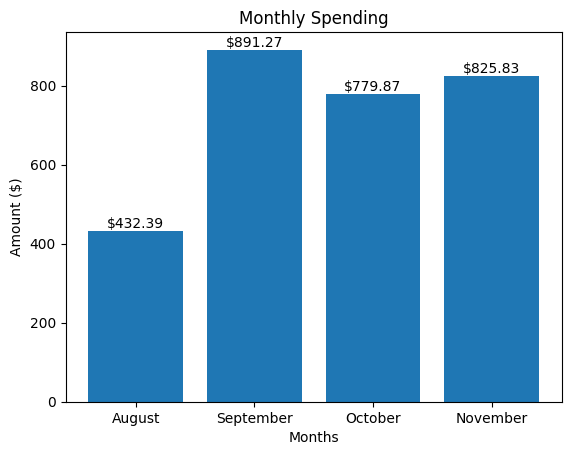

In [22]:
bars = plt.bar(monthly_totals.index, monthly_totals.values)
labels = []
for amount in monthly_totals.values:
     label = f'${amount}'
     labels.append(label)

plt.bar_label(bars,labels)

plt.title('Monthly Spending')
plt.xlabel('Months')
plt.ylabel('Amount ($)')

plt.xticks(monthly_totals.index,['August','September','October','November'])

plt.show()

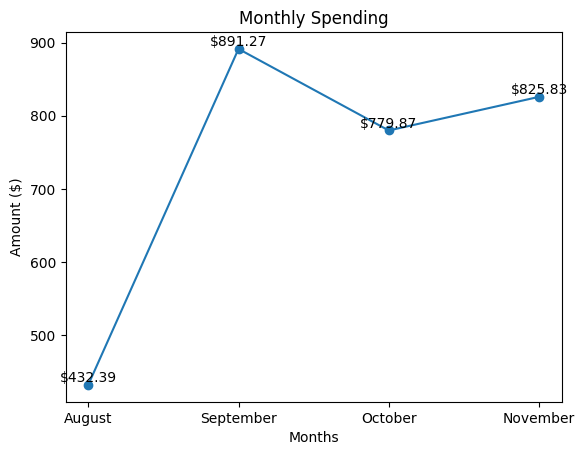

In [33]:
monthly_totals.plot(kind='line',marker='o')

plt.title('Monthly Spending')
plt.xlabel('Months')
plt.ylabel('Amount ($)')

plt.xticks(monthly_totals.index, ['August','September','October','November'])

for month,amount,label in zip(monthly_totals.index,monthly_totals.values,labels):
    plt.text(month,amount,label,ha='center',va='bottom')
plt.show()

In [36]:
help(plt.ylim)

Help on function ylim in module matplotlib.pyplot:

ylim(*args, **kwargs) -> tuple[float, float]
    Get or set the y-limits of the current Axes.

    Call signatures::

        bottom, top = ylim()  # return the current ylim
        ylim((bottom, top))   # set the ylim to bottom, top
        ylim(bottom, top)     # set the ylim to bottom, top

    If you do not specify args, you can alternatively pass *bottom* or
    *top* as kwargs, i.e.::

        ylim(top=3)  # adjust the top leaving bottom unchanged
        ylim(bottom=1)  # adjust the bottom leaving top unchanged

    Setting limits turns autoscaling off for the y-axis.

    Returns
    -------
    bottom, top
        A tuple of the new y-axis limits.

    Notes
    -----
    Calling this function with no arguments (e.g. ``ylim()``) is the pyplot
    equivalent of calling `~.Axes.get_ylim` on the current Axes.
    Calling this function with arguments is the pyplot equivalent of calling
    `~.Axes.set_ylim` on the current Axes. A